# Tema 15 — Extracción de datos de facturas con OCR y LLM

En este notebook construimos un flujo completo de **procesamiento inteligente de documentos**: descargamos un conjunto de facturas, aplicamos **OCR** con `docTR` para extraer el texto y sus coordenadas, reconstruimos la estructura del documento respetando su distribución espacial y, finalmente, usamos un **modelo de lenguaje (LLM)** servido localmente con **Ollama** para extraer los datos clave (emisor y total) en formato JSON.

> 💡 Este notebook necesita servicios locales. Revisa el `README.md` de la `semana-08` para preparar el entorno, instalar `docTR`/PyTorch y levantar **Ollama** con el modelo indicado.

**Instalación de librerias**

### ¿Qué hace este código?

Instala las **dependencias** del notebook y elige la versión correcta de **PyTorch** según tu hardware:

- `datasets` descarga el conjunto de facturas desde Hugging Face.
- `python-doctr` es el motor de **OCR** que reconoce el texto de las imágenes.
- `pandas`, `Pillow`, `matplotlib` y `mplcursors` sirven para manipular los datos y visualizar las imágenes.
- `torch` y `torchvision` son el backend de *deep learning* que usa docTR.

La celda **detecta automáticamente** si hay una **GPU NVIDIA** (comprueba si `nvidia-smi` responde):

- Si **hay GPU NVIDIA** → instala PyTorch con **CUDA 12.1** (aceleración por GPU).
- Si **no hay** (por ejemplo en **Mac** o solo CPU) → instala la versión **estándar** de PyTorch, que en Apple Silicon usa el backend `mps` y en otros equipos corre en CPU.

> 💡 Ejecuta esta celda una sola vez. Usa `subprocess` en lugar de `%pip` para poder decidir el comando de instalación de forma condicional.

In [34]:
import sys
import shutil
import subprocess

def pip_install(*args):
    subprocess.run([sys.executable, "-m", "pip", "install", *args], check=True)

# 1) Dependencias comunes
pip_install("datasets", "pandas", "Pillow", "matplotlib", "mplcursors", "scikit-learn", "python-doctr")

# 2) Detecta GPU NVIDIA: si 'nvidia-smi' existe y responde, hay GPU CUDA disponible.
tiene_nvidia = shutil.which("nvidia-smi") is not None
if tiene_nvidia:
    try:
        subprocess.run(["nvidia-smi"], check=True,
                       stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)
    except Exception:
        tiene_nvidia = False

# 3) Instala PyTorch según el hardware
if tiene_nvidia:
    print("GPU NVIDIA detectada -> instalando PyTorch con CUDA 12.1...")
    pip_install("torch", "torchvision", "--index-url", "https://download.pytorch.org/whl/cu121")
else:
    print("Sin GPU NVIDIA (Mac/CPU) -> instalando PyTorch estándar...")
    pip_install("torch", "torchvision")

Sin GPU NVIDIA (Mac/CPU) -> instalando PyTorch estándar...


**Importación, estructuración en DataFrame y exploración visual del documento de prueba**

### ¿Qué hace este código?

Carga y **explora** el conjunto de datos de prueba:

1. Descarga el dataset **`mauroibz/facturas-argentinas`** desde Hugging Face con `load_dataset`.
2. Convierte la partición de entrenamiento en un **DataFrame** de pandas para manejarla con comodidad.
3. Toma la **primera factura** (`indice = 0`) y muestra su imagen con `matplotlib` para inspeccionar visualmente el documento con el que vamos a trabajar.

Descargando dataset...


Repo card metadata block was not found. Setting CardData to empty.


Resolving data files:   0%|          | 0/503 [00:00<?, ?it/s]

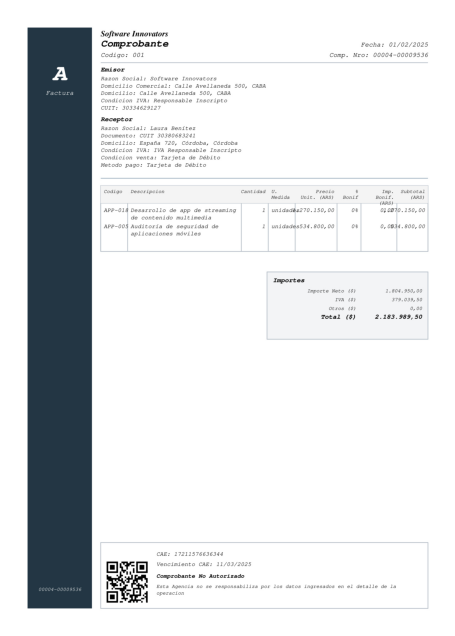

In [35]:
from datasets import load_dataset
import matplotlib.pyplot as plt
import pandas as pd
print("Descargando dataset...")
# Solo descargamos las primeras 3 facturas (en lugar de todo el dataset) para que sea rápido.
# Cambia el número o el 'indice' de abajo para probar otra factura.
dataset = load_dataset("mauroibz/facturas-argentinas", split="train[:3]")
df = pd.DataFrame(dataset)
indice = 0
ejemplo_fila = df.iloc[indice]
imagen = ejemplo_fila['image']
plt.figure(figsize=(10, 8))
plt.imshow(imagen)
plt.axis('off')
plt.show()

**Configuración del hardware de procesamiento, ejecución del modelo OCR y extracción de texto**

### ¿Qué hace este código?

Ejecuta el **OCR** sobre la factura:

1. Desactiva la verificación de certificados **SSL** para evitar el error `SSLCertVerificationError` al descargar los pesos del modelo.
2. Detecta si hay **GPU** (`cuda`) disponible y, si no, usa la **CPU**.
3. Carga el modelo **`ocr_predictor`** preentrenado de docTR y procesa la imagen convertida a un arreglo de NumPy.
4. Recorre el resultado e imprime el **texto** de las líneas ubicadas en el margen izquierdo del documento (`geometry` < 0.2).
5. `result.show()` dibuja las **cajas detectadas** sobre la imagen.

Usando dispositivo: cpu
Texto: Factura
Texto: 00004-00009536


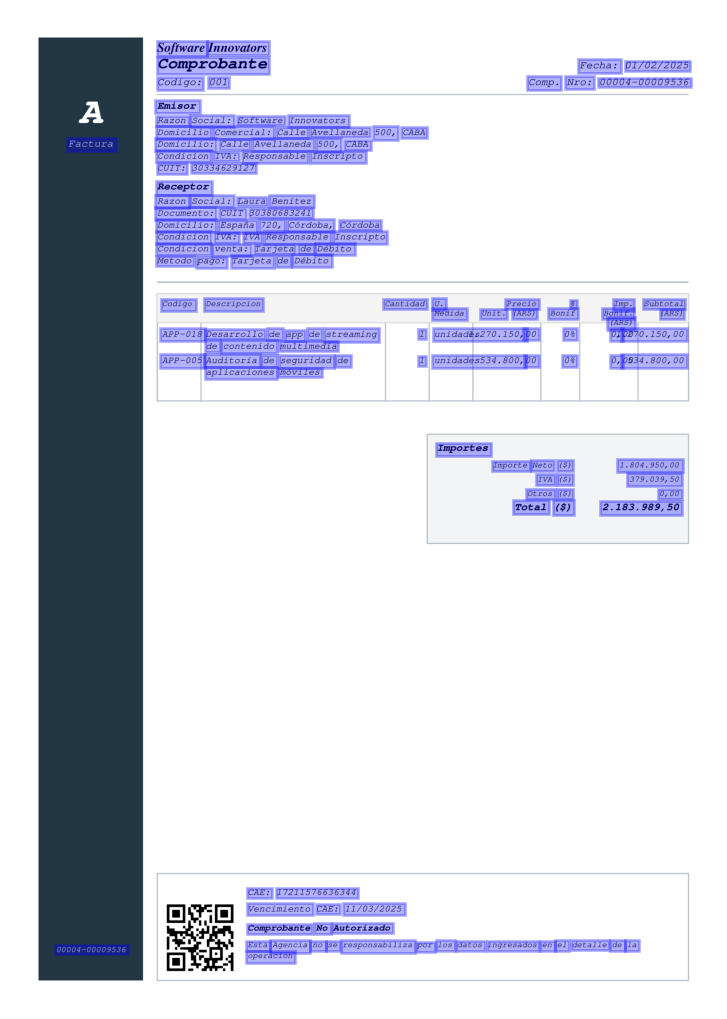

In [36]:
import ssl
# 1. Desactivar la verificación de certificados SSL (Solución al SSLCertVerificationError)
ssl._create_default_https_context = ssl._create_unverified_context
import torch
from doctr.models import ocr_predictor
import numpy as np
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Usando dispositivo: {device}")
model = ocr_predictor(pretrained=True).to(device)
img_pil = df.iloc[0]['image'].convert("RGB")
img_array = np.array(img_pil)
result = model([img_array])
output = result.export()
for page in output['pages']:
    for block in page['blocks']:
        for line in block['lines']:
            if line['geometry'][0][0] < 0.2:
                line_text = " ".join([w['value'] for w in line['words']])
                print(f"Texto: {line_text}")

result.show()

**Jerarquía geométrica del documento y estructuración del texto extraído**

### ¿Qué hace este código?

Estructura el texto detectado en una **tabla**:

1. Recorre la jerarquía que devuelve docTR (**página → bloques → líneas → palabras**).
2. Une las palabras de cada línea en una sola cadena de texto.
3. Guarda cada línea junto con su **geometría** (coordenadas de la caja) en un `DataFrame` (`df_final`) para poder ordenarlas después según su posición.

In [37]:
import pandas as pd
page = result.export()['pages'][0]
line_data = []
for block in page['blocks']:
    for line in block['lines']:
        texto = " ".join([w['value'] for w in line['words']])
        line_data.append({
            'linea': texto,
            'coordenada': line['geometry']
        })
df_final = pd.DataFrame(line_data)

**Procesamiento de coordenadas geométricas y ordenamiento espacial**

### ¿Qué hace este código?

Reconstruye el **orden de lectura** del documento a partir de las coordenadas:

1. Extrae de cada caja los valores `xmin`, `ymin` y `ymax`, y calcula el **centro vertical** (`y_center`) de cada línea.
2. Agrupa las líneas que están a la **misma altura** (`linea_y`) y las ordena de arriba hacia abajo y de izquierda a derecha.
3. Une las líneas en un texto plano (`raw_text`) que respeta la **distribución espacial** original de la factura, listo para enviarse al LLM.

In [38]:
import ast
def extraer_xmin(coord):
    if isinstance(coord, str): coord = ast.literal_eval(coord)
    return coord[0][0]

def extraer_ymin(coord):
    if isinstance(coord, str): coord = ast.literal_eval(coord)
    return coord[0][1]

def extraer_ymax(coord):
    if isinstance(coord, str): coord = ast.literal_eval(coord)
    return coord[1][1]

df = df_final.copy()
df['xmin'] = df['coordenada'].apply(extraer_xmin)
df['ymin'] = df['coordenada'].apply(extraer_ymin)
df['ymax'] = df['coordenada'].apply(extraer_ymax)
df['y_center'] = (df['ymin'] + df['ymax']) / 2
df['linea_y'] = df['y_center'].round(2)
df = df.sort_values(by=['linea_y', 'xmin'])
lineas_texto = []
for y_val, linea_group in df.groupby('linea_y', sort=False):
    texto_linea = ' \t '.join(linea_group['linea'].astype(str).str.strip())
    lineas_texto.append(texto_linea)
raw_text = "\n".join(lineas_texto)
print(raw_text)

Software Innovators
Comprobante 	 Fecha: 01/02/2025
Codigo: 001 	 Comp. Nro: 00004-00009536
Emisor
Razon Social: Software Innovators
Domicilio Comercial: Calle Avellaneda 500, CABA
Factura 	 Domicilio: Calle Avellaneda 500, CABA
Condicion IVA: Responsable Inscripto
CUIT: 30334629127
Receptor
Razon Social: Laura Benitez
Documento: CUIT 30380683241
Domicilio: Espana 720, Cordoba, Cordoba
Condicion IVA: IVA Responsable Inscripto
Condicion venta: Tarjeta de Débito
Metodo pago: Tarjeta de Débito
Cantidad U. 	 Precio 	 d
Codigo Descripcion 	 Medida Unit. (ARS) Bonif Bonif. 	 Imp. Subtotal 	 (ARS)
(ARS)
APP-018 Desarrollo de app de streaming 	 1 unidades270.150, 00 08 	 01 0070.150,00
de contenido multimedia
APP-005 Auditoria de seguridad de 	 1 unidadés534.800, 00 08 	 0, 0834.800,00
aplicaciones moviles
Importes
Importe Neto ($) 	 1.804.950,00
IVA ($) 	 379.039,50
Otros ($) 	 0,00
Total ($) 	 2.183.989,50
CAE: 17211576636344
Vencimiento CAE: 11/03/2025
Comprobante No Autorizado
00004-000095

**Diseño del prompt**

### ¿Qué hace este código?

Construye el **prompt** que guiará al modelo de lenguaje:

1. Le asigna un **rol** (experto en extracción de datos contables) y una tarea clara: identificar el **emisor** y el **total** de la factura.
2. Inserta el texto reconstruido (`raw_text`) dentro del prompt.
3. Fija **reglas estrictas**: responder únicamente en **JSON**, sin explicaciones, y usar `null` cuando falte un dato. Esto facilita procesar la respuesta de forma automática.

In [39]:
prompt = f"""
Actúa como un experto en procesamiento de documentos contables y extracción de datos (OCR Data Extraction).
Tu objetivo es analizar el texto de una factura y extraer exclusivamente la información del emisor y el monto total.

### TEXTO DE LA FACTURA:
{raw_text}

### INSTRUCCIONES DE EXTRACCIÓN:
1. Identifica el 'Emisor' buscando el nombre legal o la 'Razón Social' que encabeza el documento.
2. Identifica el 'Total' buscando el importe final después de impuestos (IVA) y otros cargos.
3. Asegúrate de que el número del total mantenga su formato original (puntos de miles y comas decimales).

### REGLAS CRÍTICAS:
- Devuelve la información ÚNICAMENTE en formato JSON.
- No incluyas explicaciones, introducciones ni comentarios adicionales.
- Si no encuentras un valor, devuelve "null".

### FORMATO DE SALIDA REQUERIDO:
{{
  "emisor": "NOMBRE_O_RAZON_SOCIAL",
  "total": "MONTO_CON_SIMBOLO_Y_DECIMALES"
}}
"""

**Conexión con la API local de Ollama**

### ¿Qué hace este código?

Envía el prompt al **LLM local** y muestra el resultado:

1. Hace una petición `POST` a la API de **Ollama** (`http://localhost:11434/api/generate`) con el modelo indicado.
2. Recibe la respuesta, la interpreta como **JSON** y extrae los campos `emisor` y `total`.
3. Imprime los datos y captura cualquier **error** de conexión o de formato.

> 💡 Requiere que **Ollama** esté en ejecución y que el modelo indicado esté descargado (`ollama pull ...`). Consulta el `README.md` de la semana.

In [40]:
import requests
import json
url = "http://localhost:11434/api/generate"
payload = {
    "model": "qwen3.5:latest",
    # Alternativa mas ligera si tienes problemas al bajar qwen3.5:latest:
    # "model": "qwen2.5:3b",
    "prompt": prompt,
    "stream": False,
    "format": "json",
    # qwen3.5 es un modelo de razonamiento: think=False manda la respuesta al campo response.
    "think": False,
}
try:
    response = requests.post(url, json=payload)
    response.raise_for_status()
    result = response.json()
    data_extraida = json.loads(result['response'])

    print("--- Datos Extraídos ---")
    print(f"Emisor: {data_extraida.get('emisor')}")
    print(f"Total:  {data_extraida.get('total')}")
except Exception as e:
    print(f"Error en la petición: {e}")

--- Datos Extraídos ---
Emisor: Software Innovators
Total:  2.183.989,50
